# Analyzing KMeans Model Results

## Setup

In [117]:
# Load Dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [104]:
# Establish BASE_DIR
try:
    BASE_DIR = Path.cwd().parent.parent
    print(f"Success! BASE_DIR is: {BASE_DIR}")
except Exception as e:
    print(f"Still failing. Current location: {Path.cwd()}")
    print(f"Error details: {e}")

Success! BASE_DIR is: /Users/amberteetsel/MSDS/DataMining/substance-abuse-predictions


In [105]:
# Pre-Defined labels, colors

# Define text labels for clusters
clustering_map = {
    0: 'Moderate Risk (Economic Protections)', # Higher wage, moderate deaths
    1: 'High Risk (Prescription-Driven)',      # Extreme Oxy levels
    2: 'Low Risk',                              # Negative values across the board
    3: 'Acute High Risk (Fentanyl-Driven)'      # Extreme Fentanyl levels
}

# color palette for clusters
color_discrete_map = {
    'Low Risk': '#2ecc71',                    # Green
    'Moderate Risk': '#f1c40f',               # Yellow
    'High Risk (Prescription-Driven)': '#e67e22', # Orange
    'Acute High Risk (Fentanyl-Driven)': '#e74c3c' # Red
}

pal = {
    'Moderate Risk': '#f1c40f', 
    'High Risk (Prescription-Driven)': '#e67e22'
}

# mapping labels
label_order = {
    'Low Risk': 0, 
    'Moderate Risk': 1, 
    'High Risk (Prescription-Driven)': 2, 
    'Acute High Risk (Fentanyl-Driven)': 3
}

# Fentanyl Spike - CDC data on when fentanyl started really coming into the country
fent_spike_year = 2013

In [106]:
# Load Data
df = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate_kmeans.csv"))
df = df.drop(columns=["Unnamed: 0"])

df_pop = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate_unscaled.csv"))
# Add col for combined oxy and fent
df_pop['oxy_fent_gms'] = df_pop['oxy_gms'] + df_pop['fent_gms']
df_pop['oxy_fent_gms'] = (df_pop['oxy_fent_gms']/df_pop['population']) * 100000
df_pop['log_oxy_fent'] = np.log1p(df_pop['oxy_fent_gms'])
# put everything in common range
scaler = StandardScaler()
df_pop['log_oxy_fent'] = scaler.fit_transform(df_pop[['log_oxy_fent']])
df_pop = df_pop[['year', 'state', 'log_oxy_fent']]

# Join new column with df
df_new = pd.merge(
    df, 
    df_pop, 
    on=['year', 'state'], 
    how='left'
)

df_new.info()
df_new.head()

df = df_new.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               850 non-null    int64  
 1   state              850 non-null    object 
 2   hydro_gms          850 non-null    float64
 3   oxy_gms            850 non-null    float64
 4   fent_gms           850 non-null    float64
 5   log_oxy            850 non-null    float64
 6   log_hydro          850 non-null    float64
 7   log_fent           850 non-null    float64
 8   gsp                850 non-null    float64
 9   unempl_rate        850 non-null    float64
 10  min_wage           850 non-null    float64
 11  medicaid_rate      850 non-null    float64
 12  log_gsp            850 non-null    float64
 13  log_unempl_rate    850 non-null    float64
 14  log_min_wage       850 non-null    float64
 15  log_medicaid_rate  850 non-null    float64
 16  snap_rate          850 non

## Research Questions

### Does higher minimum wage act as a buffer against high mortality rates, even when opioid availability is high?

We will compare the Moderate Risk cluster, characterized by a high relative minimum wage and a below-average supply of opioids, to the High Risk cluster, characterized by the worst average death rate, high relative supply of opioids, and the highest relative economic output (Gross State Product, GSP).

Our "Economic Protection" hypothesis is that higher wages correlate with lower death rates even when high drug supply is present.

**Examining Relationship Between Minimum Wage and Death Rate**

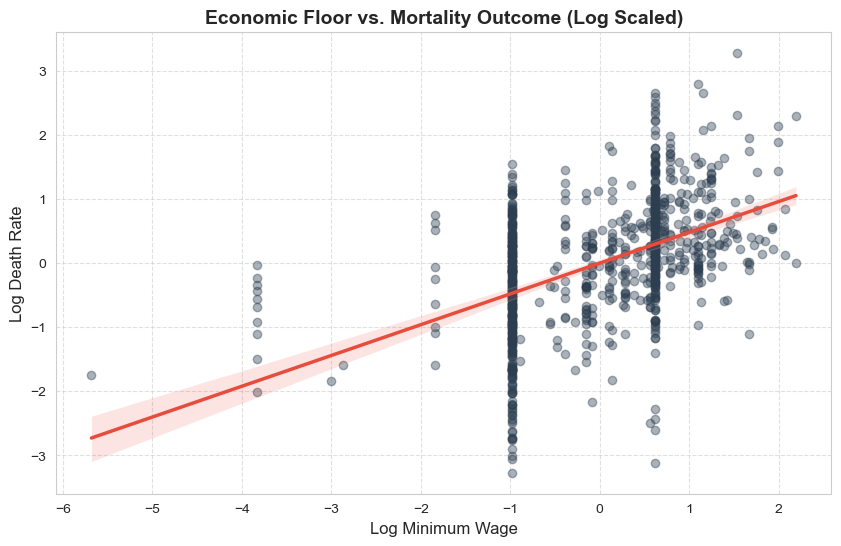

In [131]:
# plot of death vs min wage
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='log_min_wage', 
    y='log_death_rate', 
    scatter_kws={'alpha':0.4, 'color':'#2c3e50'}, 
    line_kws={'color':'#e74c3c', 'lw':2.5}
)

plt.title("Economic Floor vs. Mortality Outcome (Log Scaled)", fontsize=14, fontweight='bold')
plt.xlabel("Log Minimum Wage", fontsize=12)
plt.ylabel("Log Death Rate", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "death_v_minwage.png"), dpi=300)
plt.show()

The regression plot visualizes the overall trend in our raw data: Higher minimum wages are generally associated with higher death rates. This contradicts our initial "Economic Protection" assumption.

In [ ]:
# Isolate clusters
df_comp = df.loc[df.cluster_num.isin([0,1])].copy()

# Aggregate means
stats_comp = df_comp.groupby('cluster_lab').agg({
    'log_min_wage': 'mean',
    'log_death_rate': 'mean'
}).rename(columns={
    'log_min_wage': 'Mean Min. Wage', 
    'log_death_rate': 'Mean Death Rate'
})

# Calculate differences between clusters
mod_mask = stats_comp.index.str.contains('Moderate')
high_mask = stats_comp.index.str.contains('Prescription')

wage_gap = stats_comp.loc[high_mask, 'Mean Min. Wage'].iloc[0] - \
           stats_comp.loc[mod_mask, 'Mean Min. Wage'].iloc[0]

death_gap = stats_comp.loc[high_mask, 'Mean Death Rate'].iloc[0] - \
            stats_comp.loc[mod_mask, 'Mean Death Rate'].iloc[0]

# Add difference row
# diff_row = {'Difference': [wage_gap, death_gap]}

# something here so that diff_row becomes new row in stats_comp
stats_comp.loc['Difference'] = [wage_gap, death_gap]

# Reorder cols
stats_comp = stats_comp[['Mean Min. Wage', 'Mean Death Rate']]
stats_comp = round(stats_comp,4)

# Save comparison dataframe
stats_comp.to_csv(os.path.join(BASE_DIR, "resources", "death_rate_tables", "high-mod-wage-death-comp.csv"))

# Output the formatted dataframe
print("Comparison Table:")
display(stats_comp)

Comparison Table:


,Mean Min. Wage,Mean Death Rate
cluster_lab,,
High Risk (Prescription-Driven),0.7864,0.4759
Moderate Risk,0.6866,0.2610
Difference,0.0998,0.2149


The High Risk cluster actually has higher average minimum wages and a higher average death rate than the Low Risk clusters, further confounding our understanding of "Economic Protection".

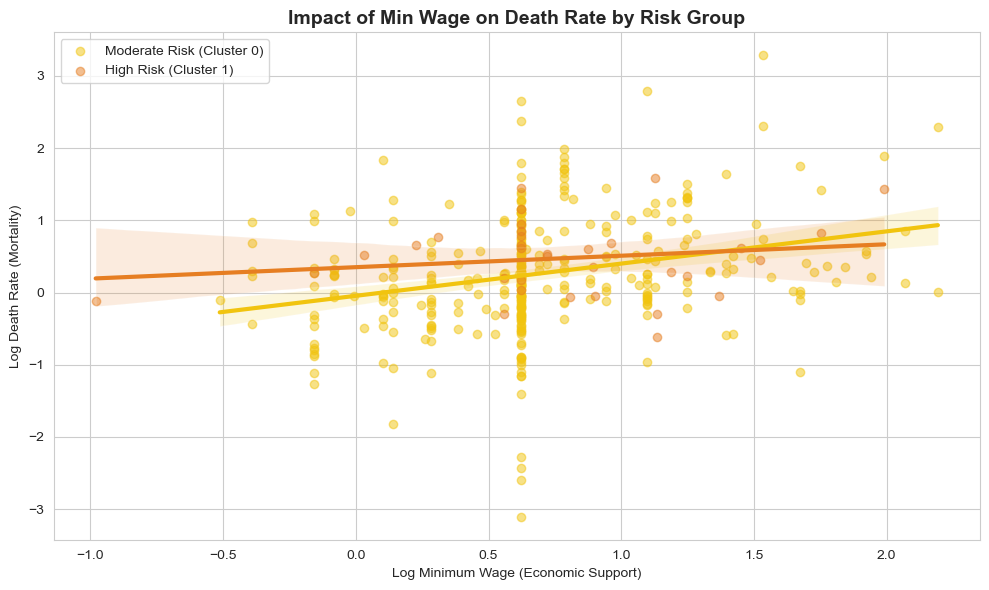

--- Moderate Risk ---
Correlation (Wage vs Death): 0.276 (p-value: 0.0000)
Avg Log Oxy: -0.114
Avg Log Fent: -0.120
Avg Log Oxy: -0.103

--- High Risk (Prescription-Driven) ---
Correlation (Wage vs Death): 0.172 (p-value: 0.3379)
Avg Log Oxy: 0.687
Avg Log Fent: 3.393
Avg Log Oxy: 1.557

--- Mean Comparisons ---


,log_min_wage,log_death_rate,log_oxy,log_fent,log_oxy_fent
cluster_lab,,,,,
High Risk (Prescription-Driven),0.786432,0.475936,0.686720,3.392592,1.556914
Moderate Risk,0.686642,0.261048,-0.113789,-0.120383,-0.103005


In [108]:
# Visualizing the "buffer effect" of minimum wages
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Regression - Is Wage Working as a Buffer?
sns.regplot(
    data=df_comp[df_comp['cluster_num'] == 0], 
    x='log_min_wage', y='log_death_rate', 
    color=color_discrete_map["Moderate Risk"], label='Moderate Risk (Cluster 0)',
    scatter_kws={'alpha':0.5}, line_kws={'lw':3}
)
sns.regplot(
    data=df_comp[df_comp['cluster_num'] == 1], 
    x='log_min_wage', y='log_death_rate', 
    color=color_discrete_map['High Risk (Prescription-Driven)'], label='High Risk (Cluster 1)',
    scatter_kws={'alpha':0.5}, line_kws={'lw':3}
)

plt.title("Impact of Min Wage on Death Rate by Risk Group", fontsize=14, fontweight='bold')
plt.xlabel("Log Minimum Wage (Economic Support)")
plt.ylabel("Log Death Rate (Mortality)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Statistics
for cluster in [0, 1]:
    subset = df_comp[df_comp['cluster_num'] == cluster]
    corr, p = stats.pearsonr(subset['log_min_wage'], subset['log_death_rate'])
    name = subset['cluster_lab'].iloc[0]
    print(f"--- {name} ---")
    print(f"Correlation (Wage vs Death): {corr:.3f} (p-value: {p:.4f})")
    print(f"Avg Log Oxy: {subset['log_oxy'].mean():.3f}")
    print(f"Avg Log Fent: {subset['log_fent'].mean():.3f}")
    print(f"Avg Log Oxy: {subset['log_oxy_fent'].mean():.3f}\n")

# Summary Stats
summary = df_comp.groupby('cluster_lab')[['log_min_wage', 'log_death_rate', 'log_oxy', 'log_fent', 'log_oxy_fent']].mean()
print("--- Mean Comparisons ---")
display(summary)

We have already established that the High Risk cluster has a higher average minimum wage than the Moderate Risk cluster. Yet, the death rate for the High Risk cluster is $1.8 \times$ higher than the death rate for the Moderate Risk cluster. It seems the drug supply is responsible for the contradiction in our initial assumption. The High Risk cluster has a well above-average Oxycodone supply $(0.687)$ and an extremely high supply of Fentanyl $(3.392)$, whereas the Moderare Risk cluster has below average supplies of Oxy and Fentanyl $(-0.114, -0.120)$, respectively.

We thus posit that in states with extreme opioid availability, the "Economic Protection" offered by higher wages is overwhelmed by the influence of drug supply.

--- Correlation Matrix (Log Scale) ---
log_min_wage      1.000000
log_fent          0.378939
log_oxy           0.444758
log_oxy_fent      0.388703
log_death_rate    0.480337
Name: log_min_wage, dtype: float64


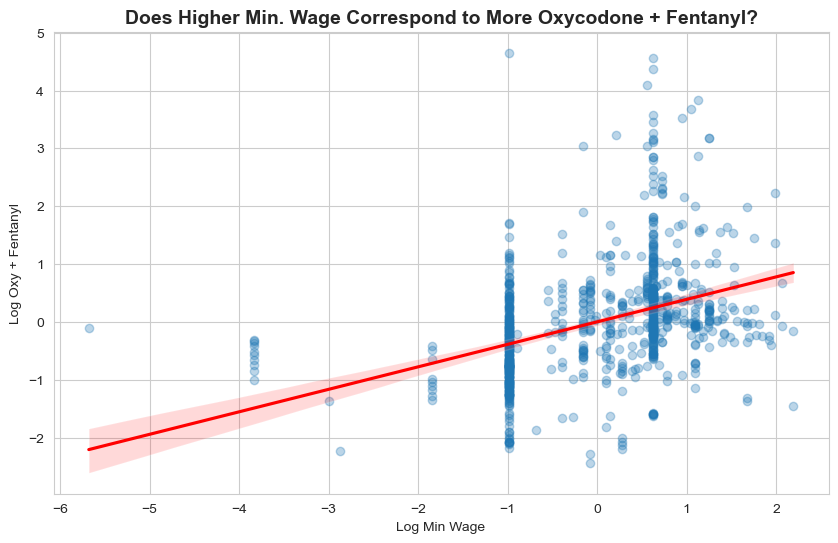

In [116]:
# Correlation Analysis: Is Minimum Wage a proxy for Fentanyl supply?
# We want to see if log_min_wage is more strongly correlated with log_fent than it is with deaths.
correlations = df[['log_min_wage', 'log_fent', 'log_oxy', 'log_oxy_fent', 'log_death_rate']].corr()
print("--- Correlation Matrix (Log Scale) ---")
print(correlations['log_min_wage'])

# Oxy/Fent vs. Min Wage
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='log_min_wage', y='log_oxy_fent', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Does Higher Min. Wage Correspond to More Oxycodone + Fentanyl?", fontsize=14, fontweight='bold')
plt.xlabel("Log Min Wage")
plt.ylabel("Log Oxy + Fentanyl")
plt.show()

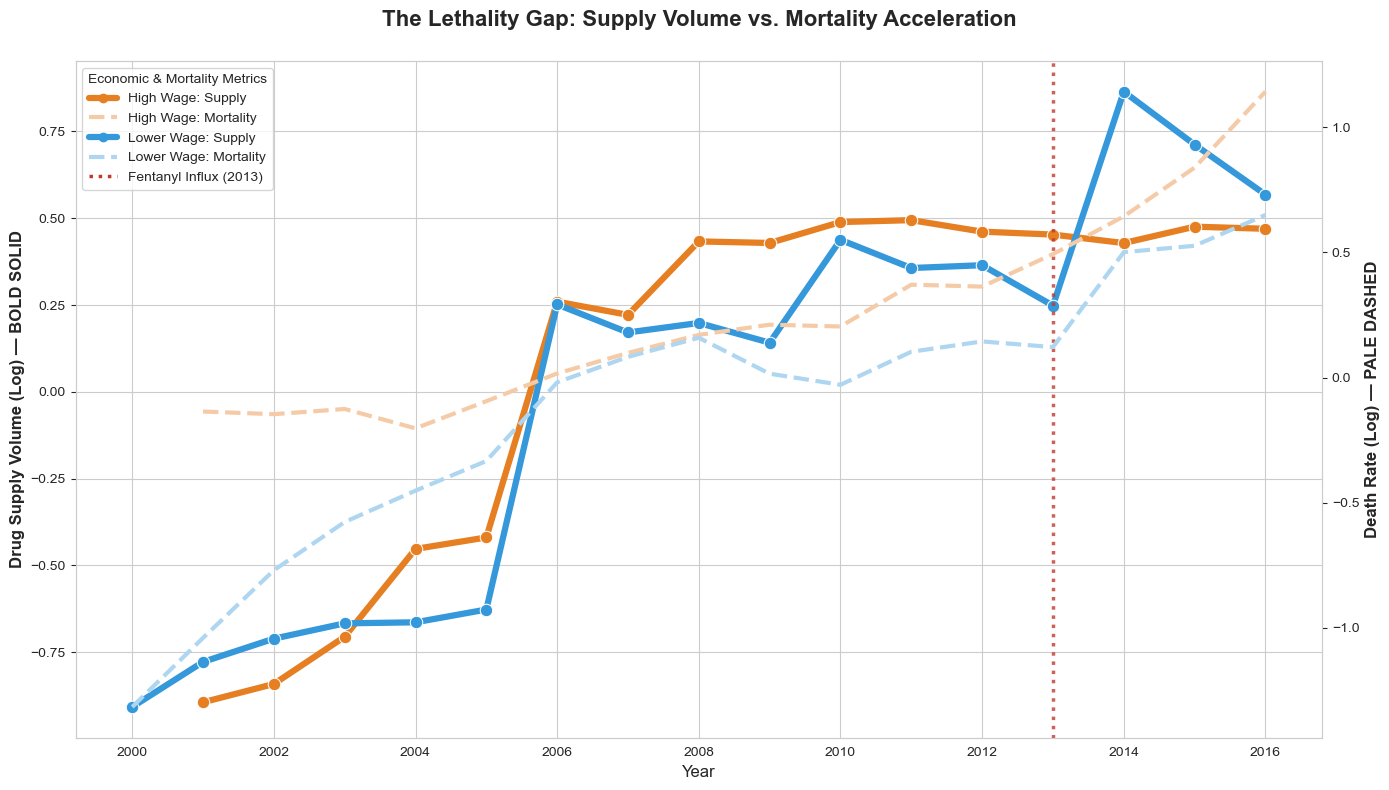

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Define Categories and Colors
# Using median split to handle evolving economic standards
median_wage = df['log_min_wage'].median()
df['wage_category'] = np.where(df['log_min_wage'] >= median_wage, 'Higher Wage States', 'Lower Wage States')

# Define Palette: Solid for Supply, Pale for Mortality
colors_solid = {'Higher Wage States': '#e67e22', 'Lower Wage States': '#3498db'}
colors_pale = {'Higher Wage States': '#f5cba7', 'Lower Wage States': '#aed6f1'}

# 2. Setup Figure and Dual Axes
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid") # Keeps gridlines for the Primary Axis (Supply)
ax1 = plt.gca() 
ax2 = ax1.twinx()

# --- CRITICAL: Remove the gridlines for the secondary axis ---
ax2.grid(False)

# 3. Plot Drug Supply (Primary Axis: BOLD, Solid, with Markers)
for category, color in colors_solid.items():
    subset = df[df['wage_category'] == category]
    sns.lineplot(
        data=subset, x='year', y='log_oxy_fent', 
        color=color, linewidth=4.5, marker='o', markersize=9, 
        errorbar=None, ax=ax1, label=f"{category} (Supply)"
    )

# 4. Plot Death Rate (Secondary Axis: PALE, Dashed, NO Markers)
for category, color in colors_pale.items():
    subset = df[df['wage_category'] == category]
    sns.lineplot(
        data=subset, x='year', y='log_death_rate', 
        color=color, linewidth=3, linestyle='--', 
        errorbar=None, ax=ax2, label=f"{category} (Mortality)"
    )

# 5. Add Reference and Formatting
ax1.axvline(x=fent_spike_year, color='#c0392b', linestyle=':', linewidth=2.5, alpha=0.8)

# Axis Labels
ax1.set_ylabel("Drug Supply Volume (Log) — BOLD SOLID", fontsize=12, fontweight='bold')
ax2.set_ylabel("Death Rate (Log) — PALE DASHED", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year", fontsize=12)

# Custom Unified Legend
legend_elements = [
    Line2D([0], [0], color=colors_solid['Higher Wage States'], lw=4.5, marker='o', label='High Wage: Supply'),
    Line2D([0], [0], color=colors_pale['Higher Wage States'], lw=3, ls='--', label='High Wage: Mortality'),
    Line2D([0], [0], color=colors_solid['Lower Wage States'], lw=4.5, marker='o', label='Lower Wage: Supply'),
    Line2D([0], [0], color=colors_pale['Lower Wage States'], lw=3, ls='--', label='Lower Wage: Mortality'),
    Line2D([0], [0], color='#c0392b', ls=':', lw=2.5, label='Fentanyl Influx (2013)')
]
ax1.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=10, title="Economic & Mortality Metrics")

# Cleanup
if ax2.get_legend(): ax2.get_legend().remove()

plt.title("The Lethality Gap: Supply Volume vs. Mortality Acceleration", fontsize=16, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

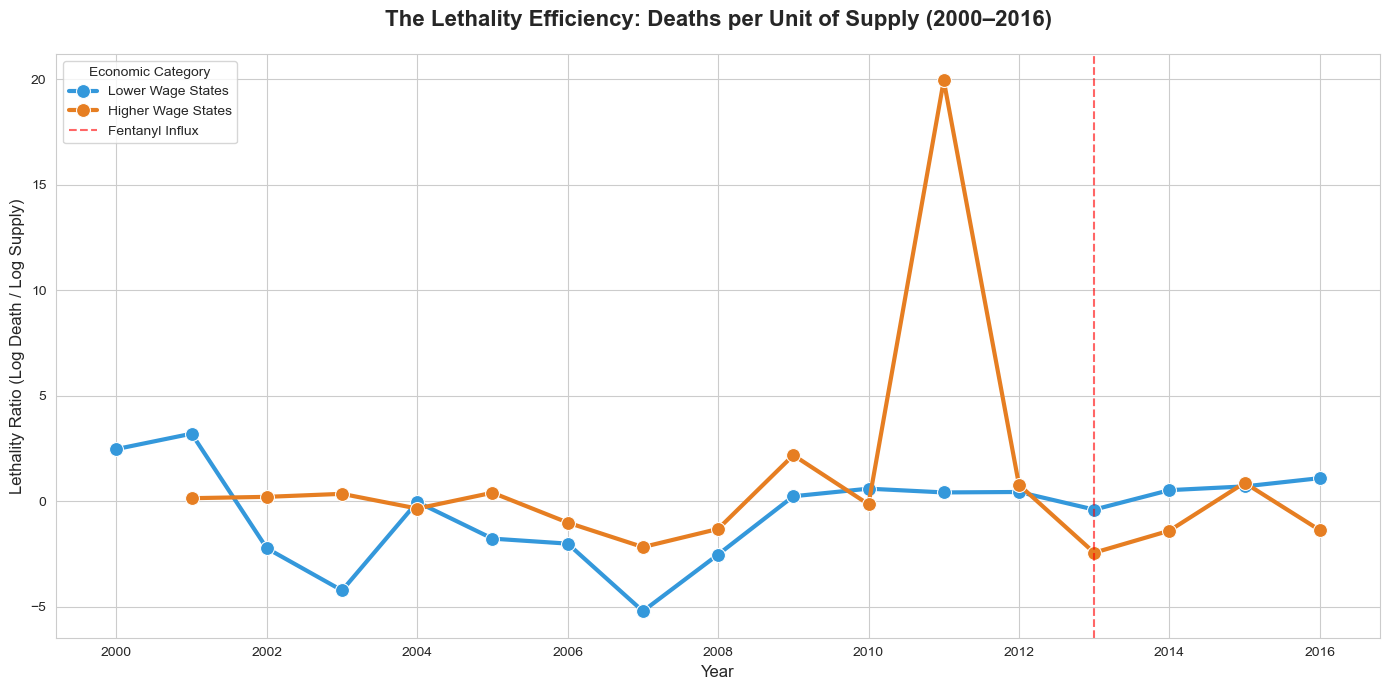

In [119]:
# 1. Calculate the Ratio (as you did)
df['lethality_ratio'] = df['log_death_rate'] / df['log_oxy_fent']

# 2. Setup the Plot
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Colors to match your previous trajectory plot
colors = {'Higher Wage States': '#e67e22', 'Lower Wage States': '#3498db'}

# 3. Plot the Average Lethality over Time
sns.lineplot(
    data=df, 
    x='year', 
    y='lethality_ratio', 
    hue='wage_category', 
    palette=colors,
    marker='o',
    markersize=10,
    linewidth=3,
    errorbar=None
)

# 4. Contextual Annotations
plt.axvline(x=fent_spike_year, color='red', linestyle='--', alpha=0.6, label='Fentanyl Influx')

# # Add the 'Lethality Gap' annotation
# plt.text(2013, 1.5, "7x Lethality Gap", fontsize=14, fontweight='bold', color='#e67e22')

# Formatting
plt.title("The Lethality Efficiency: Deaths per Unit of Supply (2000–2016)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Lethality Ratio (Log Death / Log Supply)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(title="Economic Category", loc='upper left')

plt.tight_layout()
plt.show()

In [120]:
# Build Models
# 'Naive Model', only looks at minimum wage
model_naive = smf.ols('log_death_rate ~ log_min_wage', data=df).fit()
wage_coef_naive = model_naive.params['log_min_wage']
r2_naive = model_naive.rsquared

# 'Controlled Model', accounts for oxy and fent
model_controlled = smf.ols('log_death_rate ~ log_min_wage + log_fent + log_oxy', data=df).fit()
wage_coef_controlled = model_controlled.params['log_min_wage']
fent_coef_controlled = model_controlled.params['log_fent']
oxy_coef_controlled = model_controlled.params['log_oxy']
r2_controlled = model_controlled.rsquared

# 'Interactive Model', 
model_interact = smf.ols('log_death_rate ~ log_fent + log_oxy + log_min_wage*log_oxy_fent', data=df_comp).fit()
wage_coef_interact = model_interact.params['log_min_wage']
fent_coef_interact = model_interact.params['log_fent']
oxy_coef_interact = model_interact.params['log_oxy']
drug_coef_interact = model_interact.params['log_oxy_fent']
drug_wage_coef_interact = model_interact.params['log_min_wage:log_oxy_fent']
r2_interact = model_interact.rsquared

In [121]:
# Helper function to round and add asterisk for significance
def format_sig(val, p_val, alpha=0.05):
    if val is None or val == '-' or np.isnan(val):
        return '-'
    
    formatted_val = f"{val:.4f}"
    if p_val is not None and p_val < alpha:
        return f"{formatted_val}*"
    return formatted_val

# Comparison Dictionary, raw values
data = {
    "R-Squared": [model_naive.rsquared, model_controlled.rsquared, model_interact.rsquared],
    
    "WageCoef": [model_naive.params['log_min_wage'], 
                 model_controlled.params['log_min_wage'], 
                 model_interact.params['log_min_wage']],
    "Wage_P":   [model_naive.pvalues['log_min_wage'], 
                 model_controlled.pvalues['log_min_wage'], 
                 model_interact.pvalues['log_min_wage']],

    "FentCoef": [None, 
                 model_controlled.params['log_fent'], 
                 model_interact.params['log_fent']],
    "Fent_P":   [None, 
                 model_controlled.pvalues['log_fent'], 
                 model_interact.pvalues['log_fent']],

    "OxyCoef":  [None, 
                 model_controlled.params['log_oxy'], 
                 model_interact.params['log_oxy']],
    "Oxy_P":    [None, 
                 model_controlled.pvalues['log_oxy'], 
                 model_interact.pvalues['log_oxy']],

    "OxyFentCoef": [None, None, model_interact.params.get('log_oxy_fent')],
    "OxyFent_P":   [None, None, model_interact.pvalues.get('log_oxy_fent')],

    "DrugWageCoef": [None, None, model_interact.params.get('log_min_wage:log_oxy_fent')],
    "DrugWage_P":   [None, None, model_interact.pvalues.get('log_min_wage:log_oxy_fent')]
}

# Formatting
formatted_rows = []
for i in range(3): # For Naive, Controlled, Interactive
    row = {
        "R-Squared": f"{data['R-Squared'][i]:.4f}",
        "WageCoef": format_sig(data['WageCoef'][i], data['Wage_P'][i]),
        "FentCoef": format_sig(data['FentCoef'][i], data['Fent_P'][i]),
        "OxyCoef": format_sig(data['OxyCoef'][i], data['Oxy_P'][i]),
        "OxyFentCoef": format_sig(data['OxyFentCoef'][i], data['OxyFent_P'][i]),
        "OxyFent:WageCoef": format_sig(data['DrugWageCoef'][i], data['DrugWage_P'][i])
    }
    formatted_rows.append(row)

# Final comparison dataframe
model_comparison_df = pd.DataFrame(formatted_rows, index=['Naive', 'Controlled', 'Interactive'])

print("--- Final Model Comparison Table (Alpha = 0.05, Significance = *) ---")
display(model_comparison_df)

--- Final Model Comparison Table (Alpha = 0.05, Significance = *) ---


,R-Squared,WageCoef,FentCoef,OxyCoef,OxyFentCoef,OxyFent:WageCoef
Naive,0.2307,0.4803*,-,-,-,-
Controlled,0.3279,0.3192*,0.0519,0.3182*,-,-
Interactive,0.2133,0.3297*,-0.1373*,0.5903*,-0.0005,0.1559*


In [122]:
txt_naive = """
    The 'Naive' Model seems to imply higher wages cause drug deaths, an oversimplistic and spurious conclusion.
"""

txt_controlled = """
    The 'Controlled' Model has the best overall fit based on R-Squared. 
    It shows Oxycodone supply as the most significant driver of drug deaths.
    Despite the effect of interaction between drug supply and minimum wage (discussed below), the Controlled Model remains the strongest predictor
    of death rate; thus, Oxycodone is assumed to be a primary driver of mortality regardless of economic protections.
"""

txt_interact = """
    The 'Interactive' Model reveals a statistically significant interaction effect between minimum wage and overall drug supply.
    The correlation suggests a synergy where higher-wage environments potentially exacerbate the opioid crisis.
    This may be due to the nature of high-wage states in that they are an attractive market for illicit drugs (disposable income),
    and may be more urbanized.
"""

#### Conclusion

### Which socioeconomic factors have the strongest correlation with overdose?